# My First Notebook — Python for Geoscientists, Video 1

This notebook follows along with **Video 1** of the *Python for Geoscientists* series
on [Bots on the Ground](https://botsontheground.com).

By the end of this notebook you will have:

1. Run your first piece of Python code
2. Worked with variables
3. Loaded a real drillhole dataset
4. Computed some simple statistics from it

Watch the video here: [Python for Geoscientists, Part 1](https://youtu.be/02YymGb9y_Y)

If you're new to notebooks: a notebook is made of *cells*. Some cells are text (like this one),
and some are code. To run a code cell, click on it and press **Shift + Enter**.


## 1. Hello, geologist

The first thing every Python tutorial does is print "Hello, world." We'll do the
same, with a small geological twist. Run the cell below.


In [1]:
print("Hello from a geologist")

Hello from a geologist


## 2. Variables

A *variable* is a name you give to a value, so you can use it later.

Text values go in quotes. Numbers do not. That's most of what you need to know
for now.


In [2]:
hole_id = "DDH-001"
grade_gpt = 4.7

print(hole_id)
print(grade_gpt)

DDH-001
4.7


You can use variables in calculations:


In [3]:
interval_length_m = 4.5
contained_metal_g_per_t = grade_gpt * interval_length_m

print(f"A {interval_length_m} m interval at {grade_gpt} g/t is worth {contained_metal_g_per_t} gram-metres")

A 4.5 m interval at 4.7 g/t is worth 21.150000000000002 gram-metres


## 3. Loading a real dataset

This is where Python becomes genuinely useful. We'll load a small drillhole assay
file with `pandas`, a library built for working with tabular data.

**Before running the next cell**, make sure `assays.csv` is uploaded to Colab.
In Colab: click the folder icon on the left sidebar, then drag `assays.csv` into it.

If you're running this notebook locally (with Jupyter or Anaconda), put `assays.csv`
in the same folder as the notebook.


In [4]:
import pandas as pd

df = pd.read_csv(r"/home/rexdev/Documents/critical-minerals-canada/video1/assays.csv")
df

,HoleID,From_m,To_m,Length_m,Au_gpt,Cu_pct,Lithology
0,DDH-001,0.0,2.0,2.0,0.02,0.01,Overburden
1,DDH-001,2.0,5.0,3.0,0.05,0.03,Weathered tonalite
2,DDH-001,5.0,12.5,7.5,0.18,0.05,Tonalite
3,DDH-001,12.5,18.0,5.5,1.24,0.08,Sheared tonalite
4,DDH-001,18.0,22.5,4.5,4.78,0.12,Quartz vein zone
5,DDH-001,22.5,28.0,5.5,6.32,0.15,Quartz vein zone
6,DDH-001,28.0,33.5,5.5,2.41,0.09,Sheared tonalite
7,DDH-001,33.5,40.0,6.5,0.31,0.04,Tonalite
8,DDH-001,40.0,50.0,10.0,0.08,0.02,Tonalite
9,DDH-002,0.0,3.0,3.0,0.01,0.01,Overburden


In [5]:
# Summary statistics for all numeric columns
df.describe()

,From_m,To_m,Length_m,Au_gpt,Cu_pct
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,17.047619,23.714286,6.666667,0.810000,0.167619
std,13.690238,15.152204,2.851900,1.689473,0.299965
min,0.000000,2.000000,2.000000,0.010000,0.010000
25%,3.000000,12.000000,5.500000,0.040000,0.020000
50%,18.000000,22.500000,6.500000,0.080000,0.030000
75%,28.000000,35.000000,8.500000,0.420000,0.120000
max,40.000000,50.000000,13.000000,6.320000,1.120000


In [6]:
# Compute the mean gold grade across all intervals
df["Au_gpt"].mean()

np.float64(0.8100000000000003)

You just loaded a drillhole dataset and computed the mean gold grade. In four lines
of code. That's data science.


### 5.1 Filtering rows

Often you only want part of your data. Here we look at intervals from a single hole:


In [7]:
ddh001 = df[df["HoleID"] == "DDH-001"]
ddh001

,HoleID,From_m,To_m,Length_m,Au_gpt,Cu_pct,Lithology
0,DDH-001,0.0,2.0,2.0,0.02,0.01,Overburden
1,DDH-001,2.0,5.0,3.0,0.05,0.03,Weathered tonalite
2,DDH-001,5.0,12.5,7.5,0.18,0.05,Tonalite
3,DDH-001,12.5,18.0,5.5,1.24,0.08,Sheared tonalite
4,DDH-001,18.0,22.5,4.5,4.78,0.12,Quartz vein zone
5,DDH-001,22.5,28.0,5.5,6.32,0.15,Quartz vein zone
6,DDH-001,28.0,33.5,5.5,2.41,0.09,Sheared tonalite
7,DDH-001,33.5,40.0,6.5,0.31,0.04,Tonalite
8,DDH-001,40.0,50.0,10.0,0.08,0.02,Tonalite


Or just the high-grade intervals (anything above 1 g/t Au):


In [8]:
high_grade = df[df["Au_gpt"] > 1.0]
high_grade

,HoleID,From_m,To_m,Length_m,Au_gpt,Cu_pct,Lithology
3,DDH-001,12.5,18.0,5.5,1.24,0.08,Sheared tonalite
4,DDH-001,18.0,22.5,4.5,4.78,0.12,Quartz vein zone
5,DDH-001,22.5,28.0,5.5,6.32,0.15,Quartz vein zone
6,DDH-001,28.0,33.5,5.5,2.41,0.09,Sheared tonalite


### 5.2 Group statistics

`groupby` is one of the most powerful tools in pandas. It lets you compute
statistics per group — for example, mean grade by drillhole:


In [9]:
df.groupby("HoleID")["Au_gpt"].mean()

HoleID
DDH-001    1.71
DDH-002    0.21
DDH-003    0.03
Name: Au_gpt, dtype: float64

Or per lithology, which is genuinely useful for exploration geology:


In [10]:
df.groupby("Lithology")[["Au_gpt", "Cu_pct"]].mean().round(3)

,Au_gpt,Cu_pct
Lithology,,
Altered diorite,0.180,0.395
Chalcopyrite zone,0.500,0.995
Diorite,0.050,0.025
Granodiorite,0.035,0.020
Overburden,0.013,0.010
Quartz vein zone,5.550,0.135
Sheared tonalite,1.825,0.085
Tonalite,0.190,0.037
Weathered tonalite,0.050,0.030


### 5.3 A simple plot

`matplotlib` is the standard plotting library. Here's a downhole plot of gold
grade for DDH-001 — exactly the kind of figure you'd put in a report.


In [11]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for font_file in (Path(sys.prefix) / "fonts").glob("Roboto-*.ttf"):
    fm.fontManager.addfont(str(font_file))

BG_COLOR = "#270000"
TEXT_COLOR = "white"

plt.rcParams.update({
    "font.family": "Roboto",
    "figure.facecolor": BG_COLOR,
    "axes.facecolor": BG_COLOR,
    "savefig.facecolor": BG_COLOR,
    "text.color": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "axes.edgecolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
})


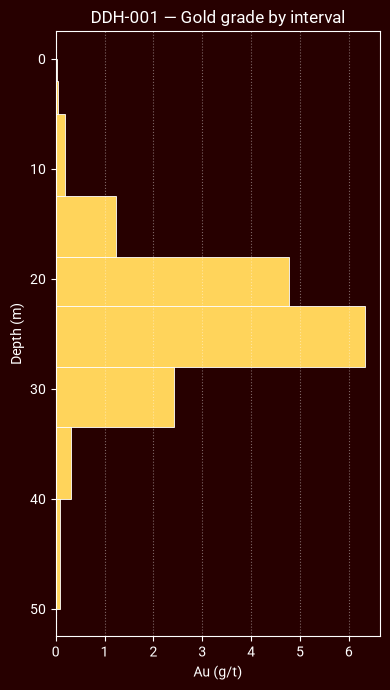

In [12]:
ddh001 = df[df["HoleID"] == "DDH-001"]

fig, ax = plt.subplots(figsize=(4, 7))
ax.barh(ddh001["From_m"], ddh001["Au_gpt"], height=ddh001["Length_m"],
        color="#ffd45b", edgecolor="white", linewidth=0.6, align="edge")

ax.invert_yaxis()
ax.set_xlabel("Au (g/t)")
ax.set_ylabel("Depth (m)")
ax.set_title("DDH-001 — Gold grade by interval")
ax.grid(axis="x", linestyle=":", alpha=0.4, color="white")

plt.tight_layout()
plt.show()

That high-grade interval between 18 and 28 metres jumps out immediately — much
clearer than scanning a column of numbers.

We'll cover plotting properly in Video 3.


In [13]:
def weighted_mean_grade(grades, lengths):
    """Return the length-weighted mean of a series of grades.

    A 10 m interval at 1 g/t counts twice as much as a 5 m interval at 1 g/t.
    """
    total_metal = 0
    total_length = 0
    for grade, length in zip(grades, lengths):
        total_metal = total_metal + (grade * length)
        total_length = total_length + length
    return total_metal / total_length

# Try it on some intervals
sample_grades = [0.05, 4.78, 6.32, 0.31]
sample_lengths = [3.0, 4.5, 5.5, 6.5]

avg = weighted_mean_grade(sample_grades, sample_lengths)
print(f"Length-weighted mean: {avg:.2f} g/t")

Length-weighted mean: 3.00 g/t


In [14]:
def classify_grade(grade_gpt):
    if grade_gpt > 5.0:
        return "high grade"
    elif grade_gpt > 1.0:
        return "mineralized"
    else:
        return "below cutoff"

# Use it
print(classify_grade(4.78))
print(classify_grade(0.18))
print(classify_grade(6.32))

mineralized
below cutoff
high grade


## 6. Four more plots worth knowing

We only have three holes and 21 intervals, but that's enough to show off a few
plot types you'll reach for constantly in exploration geology: a ridgeline plot,
a downhole lithology log, a bivariate scatter, and a side-by-side comparison.
All four are built with `plotnine` below — each is a short stack of declarative
layers instead of a hand-rolled loop over matplotlib axes.

First, a shared colour scheme — so each lithology and each hole keeps the same
colour in every plot below, which makes them much easier to compare.

In [15]:
import numpy as np
from scipy.stats import gaussian_kde
from plotnine import theme, element_text, element_rect, element_line, element_blank

palette = {
    "black":         "#000000",
    "blue_1":        "#0033b0",
    "blue_2":        "#3940bb",
    "light_blue":    "#9296da",  # tint of blue_2 — 9th shade, only needed because 9 lithologies > 8 given colours
    "light_orange":  "#db9671",
    "light_purple":  "#ba7a8d",
    "orange":        "#f6b44d",
    "purple":        "#8d5eaa",
    "yellow":        "#ffd45b",
}

hole_colors = {
    "DDH-001": palette["orange"],
    "DDH-002": palette["purple"],
    "DDH-003": palette["blue_1"],
}

litho_colors = {
    "Altered diorite":    palette["blue_1"],
    "Chalcopyrite zone":  palette["purple"],
    "Diorite":            palette["light_blue"],
    "Granodiorite":       palette["light_purple"],
    "Overburden":         palette["black"],
    "Quartz vein zone":   palette["yellow"],
    "Sheared tonalite":   palette["orange"],
    "Tonalite":           palette["blue_2"],
    "Weathered tonalite": palette["light_orange"],
}

def dark_theme(**overrides):
    """Shared maroon-background, white-Roboto theme reused by every plotnine plot below."""
    base = theme(
        text=element_text(family="Roboto", color=TEXT_COLOR),
        plot_background=element_rect(fill=BG_COLOR, color=BG_COLOR),
        panel_background=element_rect(fill=BG_COLOR),
        panel_grid=element_line(color=TEXT_COLOR, alpha=0.12),
        panel_grid_minor=element_blank(),
        axis_text=element_text(color=TEXT_COLOR),
        axis_title=element_text(color=TEXT_COLOR),
        plot_title=element_text(color=TEXT_COLOR, weight="bold"),
        plot_subtitle=element_text(color=TEXT_COLOR),
        legend_background=element_rect(fill=BG_COLOR),
        legend_key=element_rect(fill=BG_COLOR),
        legend_text=element_text(color=TEXT_COLOR),
        legend_title=element_text(color=TEXT_COLOR),
        strip_background=element_rect(fill=BG_COLOR),
        strip_text=element_text(color=TEXT_COLOR),
    )
    return base + theme(**overrides)


### 6.1 Ridgeline plot — gold grade distribution by hole

A ridgeline plot stacks a density curve per group with a small vertical offset,
so you can compare shapes at a glance. Here each ridge is the distribution of
Au grades within one hole: a tall, narrow ridge means most intervals cluster
around one grade; a wide, flat one means grades are spread out.

`plotnine` has no built-in ridgeline geom, so the KDE + offset math below is
still manual — but instead of looping over `ax.plot` / `fill_between` calls,
the result is assembled into one tidy dataframe and drawn with a single
`geom_ribbon` + `geom_line` layer.

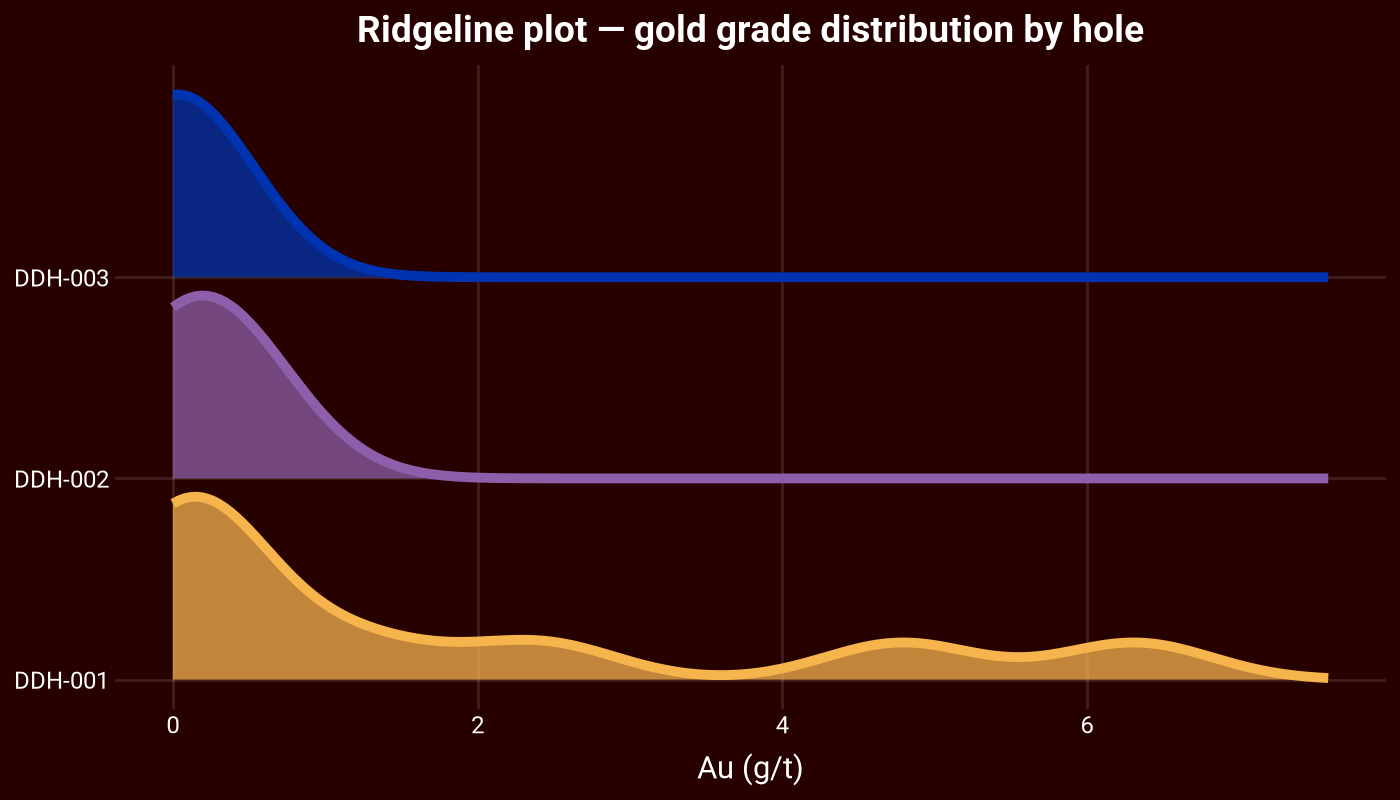

In [16]:
from plotnine import (
    ggplot, aes, geom_ribbon, geom_line, scale_fill_manual, scale_color_manual,
    scale_y_continuous, labs, theme_minimal,
)

holes = sorted(df["HoleID"].unique())
x_grid = np.linspace(0, df["Au_gpt"].max() * 1.2, 200)
ridge_step = 1.1
bandwidth = 0.5  # g/t — same physical smoothing for every ridge, so shapes stay comparable

ridge_rows = []
for i, hole in enumerate(holes):
    grades = df.loc[df["HoleID"] == hole, "Au_gpt"]
    factor = bandwidth / grades.std(ddof=1)  # scales gaussian_kde's default to our fixed bandwidth
    density = gaussian_kde(grades, bw_method=factor)(x_grid)
    density = density / density.max()  # normalise so every ridge reaches the same height
    baseline = i * ridge_step
    ridge_rows.append(pd.DataFrame({
        "Au_gpt": x_grid, "baseline": baseline, "top": density + baseline, "HoleID": hole,
    }))

ridge_df = pd.concat(ridge_rows, ignore_index=True)

(
    ggplot(ridge_df, aes(x="Au_gpt", ymin="baseline", ymax="top", group="HoleID"))
    + geom_ribbon(aes(fill="HoleID"), alpha=0.75)
    + geom_line(aes(y="top", color="HoleID"), size=2)
    + scale_fill_manual(values=hole_colors, guide=None)
    + scale_color_manual(values=hole_colors, guide=None)
    + scale_y_continuous(breaks=[i * ridge_step for i in range(len(holes))], labels=holes)
    + labs(x="Au (g/t)", y="", title="Ridgeline plot — gold grade distribution by hole")
    + theme_minimal()
    + dark_theme(figure_size=(7, 4))
)


### 6.2 Downhole lithology logs

This is the classic "strip log" geologists use to see rock type change with
depth. Each column is a hole; each coloured segment is a logged interval.
Watch how DDH-002 moves from diorite into a chalcopyrite zone — that's the
copper mineralisation showing up directly in the lithology, not just the
assays.

Built with `facet_wrap` instead of a manual loop over `ax.bar` calls — and the
legend comes for free from `scale_fill_manual` rather than a hand-built list
of `Rectangle` patches.

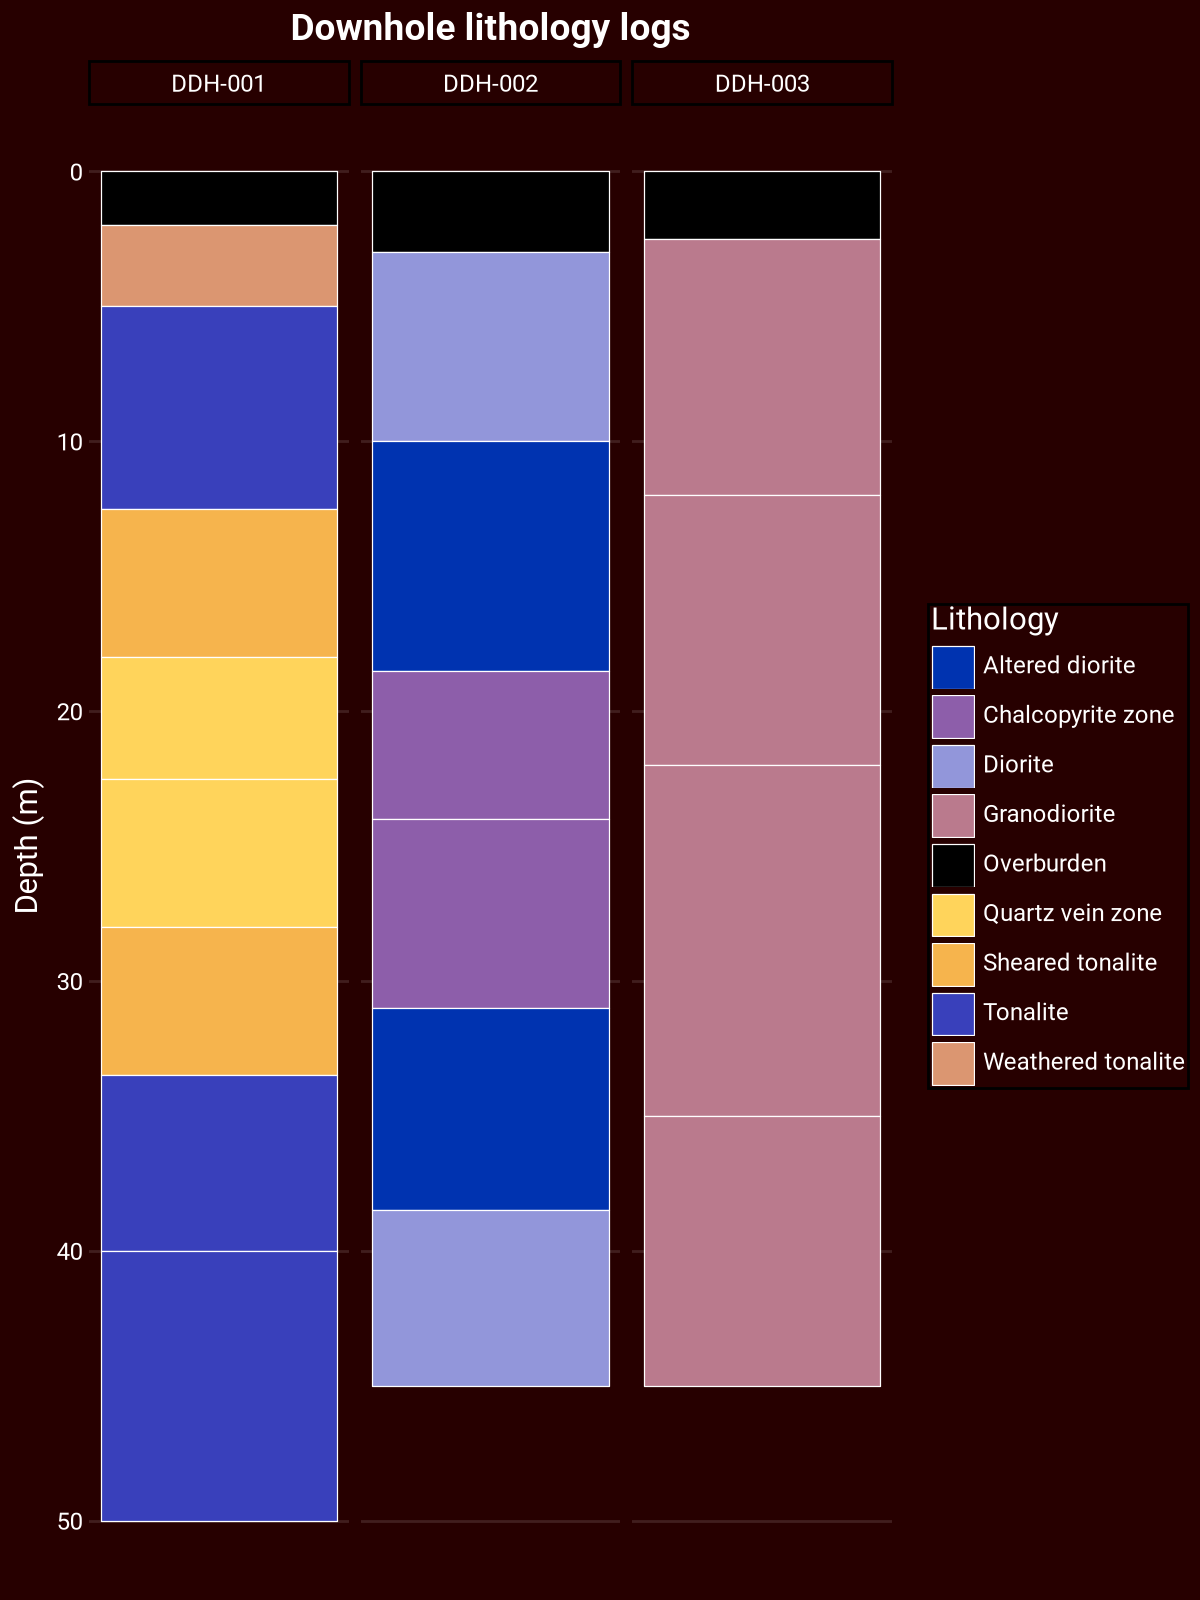

In [17]:
from plotnine import (
    ggplot, aes, geom_rect, facet_wrap, scale_y_reverse, scale_fill_manual,
    scale_x_continuous, labs, theme_minimal,
)

(
    ggplot(df, aes(xmin=0, xmax=1, ymin="From_m", ymax="To_m", fill="Lithology"))
    + geom_rect(color="white", size=0.25)
    + facet_wrap("~HoleID", nrow=1)
    + scale_y_reverse()
    + scale_fill_manual(values=litho_colors)
    + scale_x_continuous(breaks=[])  # the column width carries no meaning, only depth (y) and lithology (fill) do
    + labs(x="", y="Depth (m)", title="Downhole lithology logs")
    + theme_minimal()
    + dark_theme(figure_size=(6, 8))
)


### 6.3 Gold vs copper, coloured by lithology

A scatter plot is the fastest way to check whether two elements move together.
Here each point is one interval: colour shows lithology, and size scales
directly with Au grade, so the high-grade intervals visually "blow up". The
chalcopyrite zone and quartz vein zone points sit apart from everything else —
exactly the two lithologies flagged as ore zones above.

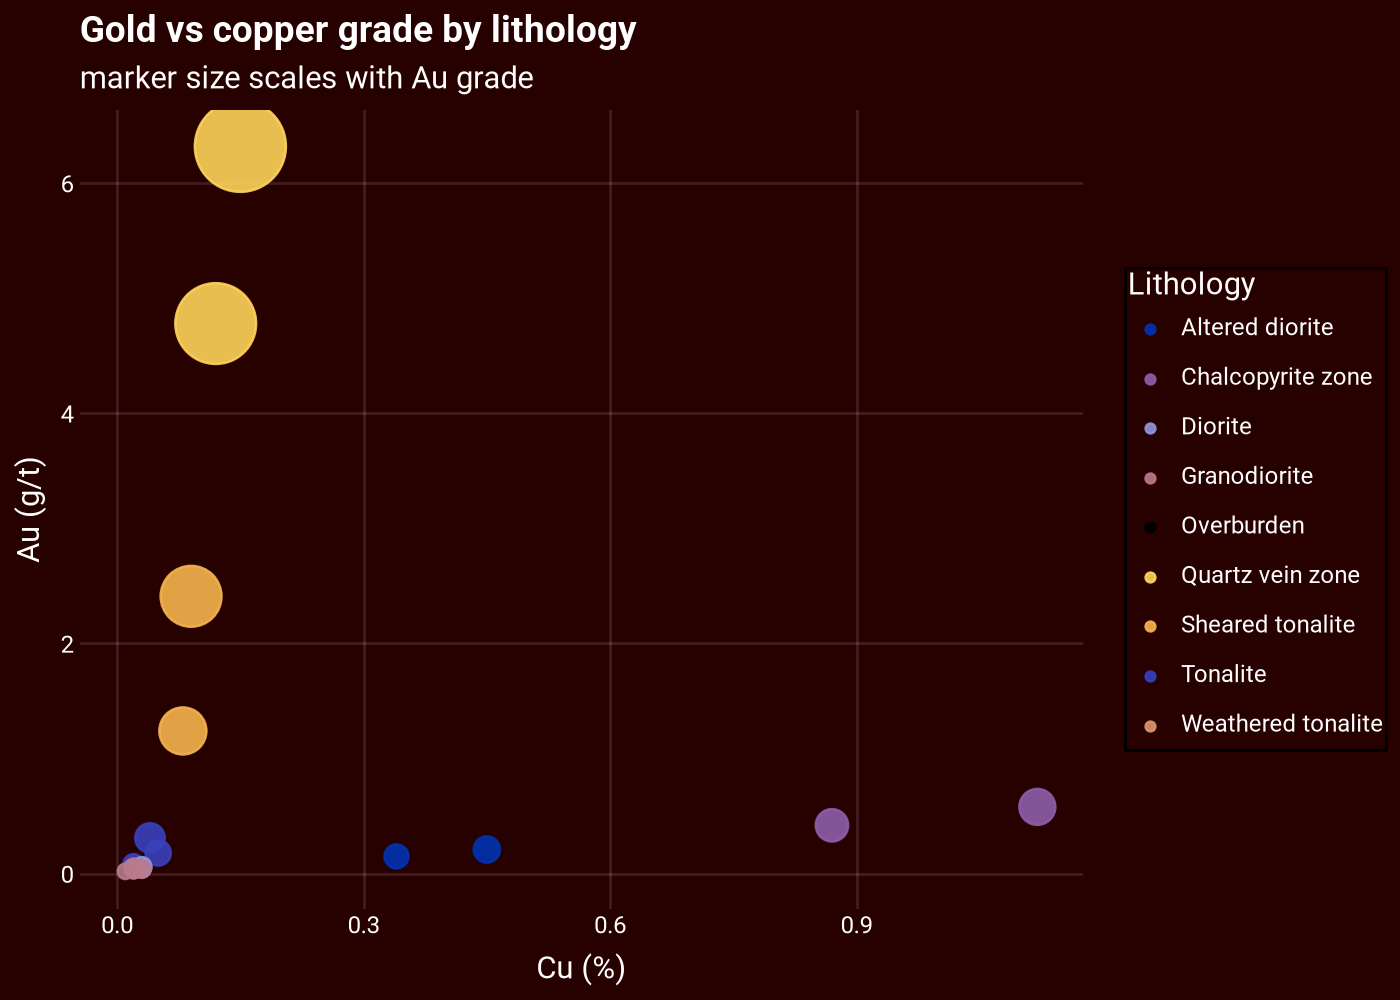

In [18]:
from plotnine import (
    ggplot, aes, geom_point, scale_size, scale_color_manual,
    labs, theme_minimal,
)

(
    ggplot(df, aes(x="Cu_pct", y="Au_gpt", color="Lithology", size="Au_gpt"))
    + geom_point(alpha=0.9)
    + scale_size(range=(2, 18), guide=None)  # size already shown via colour+position; drop the redundant legend
    + scale_color_manual(values=litho_colors)
    + labs(
        x="Cu (%)", y="Au (g/t)",
        title="Gold vs copper grade by lithology",
        subtitle="marker size scales with Au grade",
    )
    + theme_minimal()
    + dark_theme(figure_size=(7, 5))
)


### 6.4 Downhole gold grade — all holes side by side

Small multiples — one panel per hole, sharing a depth axis — let you make the
same comparison across every hole at once. Note `scales="free_x"` below:
DDH-001 runs up to 6+ g/t while DDH-003 tops out under 0.1 g/t, so a shared
x-axis would flatten DDH-003 to an invisible sliver. Each panel now gets its
own x-range instead — the cost is that you can no longer compare exact bar
lengths across panels, but here we care about *shape within each hole*, not
absolute values, so that trade is worth it.

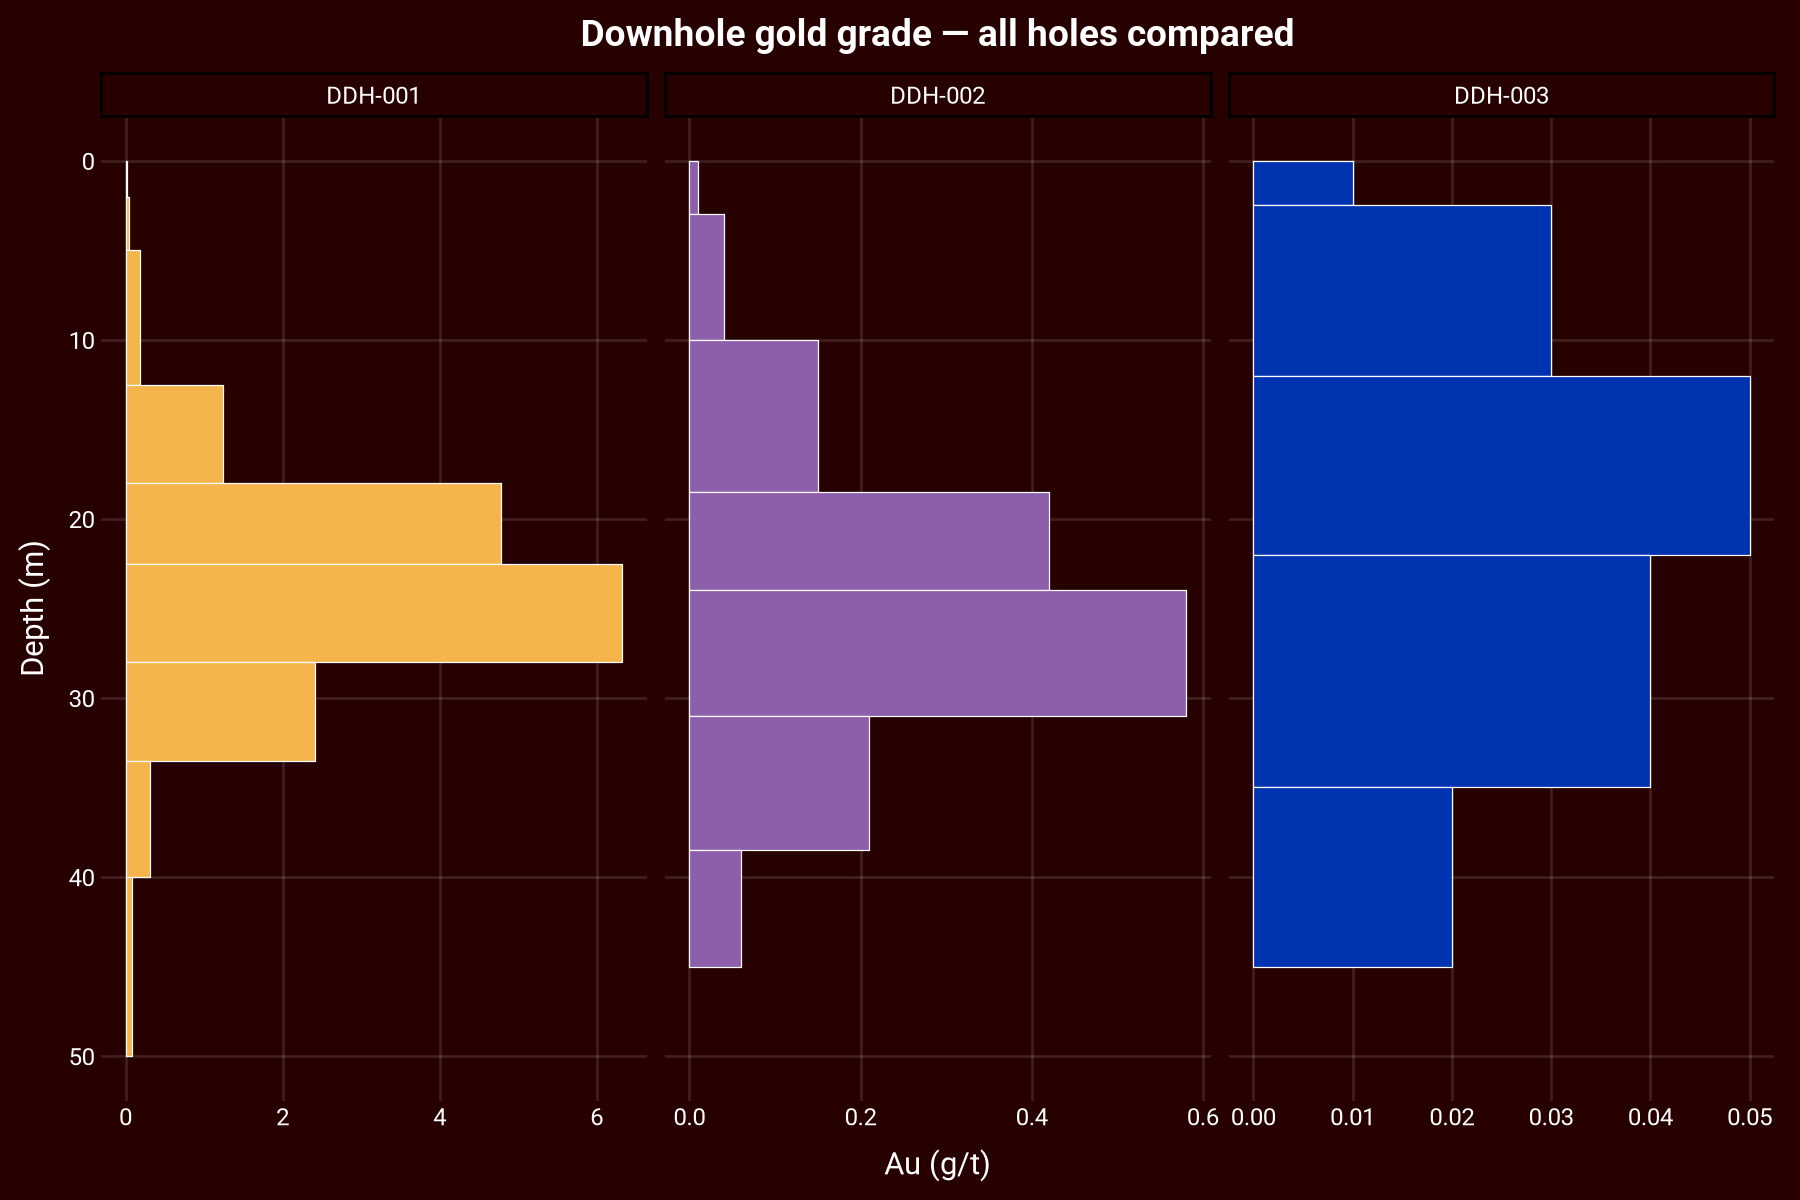

In [19]:
from plotnine import (
    ggplot, aes, geom_rect, facet_wrap, scale_y_reverse, scale_fill_manual,
    labs, theme_minimal,
)

(
    ggplot(df, aes(xmin=0, xmax="Au_gpt", ymin="From_m", ymax="To_m", fill="HoleID"))
    + geom_rect(color="white", size=0.25)
    + facet_wrap("~HoleID", scales="free_x")
    + scale_y_reverse()
    + scale_fill_manual(values=hole_colors, guide=None)
    + labs(x="Au (g/t)", y="Depth (m)", title="Downhole gold grade — all holes compared")
    + theme_minimal()
    + dark_theme(figure_size=(9, 6))
)
